In [1]:
import ee
import pandas as pd
import numpy as np
import os


#os.chdir("C:/Users/cuent/En-Peu/notebooks/")
print(os.getcwd())

ImportError: DLL load failed while importing _multiarray_umath: No se puede encontrar el módulo especificado.

ImportError: numpy._core.multiarray failed to import

In [2]:
# Cambiar al directorio padre
os.chdir("..")
parent_directory = os.getcwd()

# os.path.join() maneja correctamente las barras de ruta para diferentes SO (Windows, Linux, macOS)
file_path = os.path.join(parent_directory, 'data', 'data_fin.csv')

# Cargar el archivo CSV
data = pd.read_csv(file_path)


# Verificar la estructura del DataFrame (equivalente a str(data) en R)
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64345 entries, 0 to 64344
Data columns (total 19 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   POINT_X  64345 non-null  float64
 1   POINT_Y  64345 non-null  float64
 2   PLA      64345 non-null  float64
 3   A        64345 non-null  float64
 4   AC       64345 non-null  float64
 5   CIB      64345 non-null  float64
 6   CICCB    64345 non-null  float64
 7   DBB      64345 non-null  float64
 8   DOB      64345 non-null  float64
 9   P        64345 non-null  float64
 10  CUS_1    64345 non-null  float64
 11  CUS_2    64345 non-null  float64
 12  CUS_3    64345 non-null  float64
 13  CUS_4    64345 non-null  float64
 14  CUS_5    64345 non-null  float64
 15  OC_1     64345 non-null  float64
 16  OC_2     64345 non-null  float64
 17  OC_3     64345 non-null  float64
 18  OC_4     64345 non-null  float64
dtypes: float64(19)
memory usage: 9.3 MB
None


In [3]:
# 1. Autenticación e inicio de Earth Engine
ee.Authenticate()
ee.Initialize()

In [5]:
import geopandas as gpd
from shapely.geometry import Point
import ee
import pandas as pd

# 1. Crear GeoDataFrame con las coordenadas originales (EPSG:25830)
gdf = gpd.GeoDataFrame(
    data.copy(),
    geometry=[Point(xy) for xy in zip(data['POINT_X'], data['POINT_Y'])],
    crs='EPSG:25830'
)

# 2. Transformar a WGS84 (EPSG:4326)
gdf = gdf.to_crs('EPSG:4326')

# 3. Extraer lat/lon transformados al DataFrame
data['lon'] = gdf.geometry.x
data['lat'] = gdf.geometry.y

print(data.head())


# 4. Función para obtener embeddings AlphaEarth 2024
def fetch_embedding_2024(lon, lat):
    try:
        pt = ee.Geometry.Point([lon, lat])
        collection = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL") \
                        .filterDate("2024-01-01", "2025-01-01") \
                        .filterBounds(pt)

        if collection.size().getInfo() == 0:
            return [None] * 64

        img = collection.first()
        band_names = [f"A{str(i).zfill(2)}" for i in range(64)]
        vals = img.select(band_names).reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=pt,
            scale=10
        ).getInfo()

        return [vals.get(b) for b in band_names]

    except Exception as e:
        print(f"Error en punto ({lon}, {lat}): {e}")
        return [None] * 64



         POINT_X       POINT_Y  PLA         A        AC       CIB     CICCB  \
0  722396.507981  4.365860e+06  0.0  0.604254  0.067778  0.203910  0.390004   
1  722404.245816  4.365860e+06  0.0  0.581583  1.000000  0.201362  0.388246   
2  722411.983652  4.365860e+06  0.0  0.581583  1.000000  0.198815  0.386458   
3  722396.502336  4.365868e+06  0.0  0.609629  1.000000  0.204328  0.391055   
4  722404.240164  4.365868e+06  0.0  0.608561  1.000000  0.201762  0.389291   

        DBB       DOB         P  ...  CUS_2  CUS_3  CUS_4  CUS_5  OC_1  OC_2  \
0  0.620621  0.000000  0.077332  ...    0.0    0.0    0.0    1.0   0.0   0.0   
1  0.614835  0.788748  0.089864  ...    0.0    0.0    0.0    0.0   0.0   0.0   
2  0.610494  0.783177  0.089864  ...    0.0    0.0    0.0    0.0   0.0   0.0   
3  0.620342  0.000000  0.051674  ...    0.0    0.0    0.0    0.0   0.0   0.0   
4  0.614553  0.788748  0.062030  ...    0.0    0.0    0.0    0.0   0.0   0.0   

   OC_3  OC_4       lon        lat  
0   0.0

In [6]:
# 5. Obtener embeddings para todos los puntos (esto puede tardar)
embeddings_list = []
for idx, row in data.iterrows():
    emb = fetch_embedding_2024(row['lon'], row['lat'])
    embeddings_list.append(emb)

In [7]:
# 6. Crear DataFrame con los embeddings
embeddings_df = pd.DataFrame(embeddings_list, columns=[f'emb_{i}' for i in range(64)])

# 7. Combinar con el DataFrame original
data_with_embeddings = pd.concat([data.reset_index(drop=True), embeddings_df], axis=1)

# 8. Guardar a CSV si quieres
data_with_embeddings.to_csv("data_con_embeddings.csv", index=False)

print("Embeddings añadidos correctamente")

Embeddings añadidos correctamente


In [10]:
# 2. Contar valores faltantes por columna
print("Valores faltantes por columna:")
print(data_with_embeddings.isnull().sum())

Valores faltantes por columna:
POINT_X    0
POINT_Y    0
PLA        0
A          0
AC         0
          ..
emb_59     0
emb_60     0
emb_61     0
emb_62     0
emb_63     0
Length: 85, dtype: int64


In [19]:
# Vamos a comprobar si las coordenadas son compatibles. Vemos el formato de las nuestras

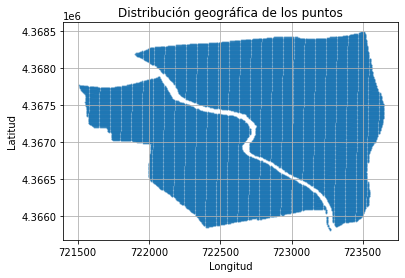

In [22]:
import matplotlib.pyplot as plt

plt.scatter(data['POINT_X'], data['POINT_Y'], s=1, alpha=0.5)
plt.title("Distribución geográfica de los puntos")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True)
plt.show()

El mapa muestra que las coordenadas no están en WGS84 (latitud/longitud), que es lo que espera Earth Engine. Hay que transformar las coordenadas.

In [11]:
import matplotlib.pyplot as plt

# Seleccionar solo columnas de embeddings
emb_cols = [col for col in data_with_embeddings.columns if col.startswith('emb_')]
emb_data = data_with_embeddings[emb_cols]

# Estadísticas descriptivas
print(emb_data.describe())

# Boxplots para ver la distribución por embedding
plt.figure(figsize=(15, 5))
emb_data.boxplot(rot=90)
plt.title("Distribución de los embeddings")
plt.show()



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\cuent\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\cuent\anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\cuent\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "C:\Users\cuent\anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "C:\Users\cuent\anaconda3\lib\site-pack

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import